# ✅ Solutions — Module 1 — Descriptive Statistics & Exploratory Data Analysis

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

### ✍️ Exercise 1.1 — *Centre*: What salary should the job ad quote? (HR analytics)

You are a people-analytics analyst at a 400-person software company. Marketing wants to write *"average salary: € …"* into a job ad. The data contains all salaries, including a handful of executives.

**Tasks**
1. Compute mean, median, 10 %-trimmed mean and mode (use €5k bins) of `salaries`.
2. Plot the distribution and mark mean and median.
3. What share of employees earns *less* than the mean?
4. Which number would you put into the ad, and how would you phrase it honestly?
5. Remove the 8 executives and recompute mean and median. What do you observe?

In [2]:
g = np.random.default_rng(101)
staff      = g.lognormal(mean=np.log(62_000), sigma=0.25, size=392)
executives = g.uniform(250_000, 900_000, size=8)
salaries = pd.Series(np.round(np.concatenate([staff, executives]), -2), name="salary_eur")
salaries.describe().round(0)

count       400.0
mean      72642.0
std       73840.0
min       27400.0
25%       51275.0
50%       62400.0
75%       74725.0
max      853100.0
Name: salary_eur, dtype: float64

mean          :     72,642 €
median        :     62,400 €
10%-trimmed   :     62,916 €
modal 5k-bin  :     55,000 – 60,000 €

Share of employees earning less than the mean: 71.2%


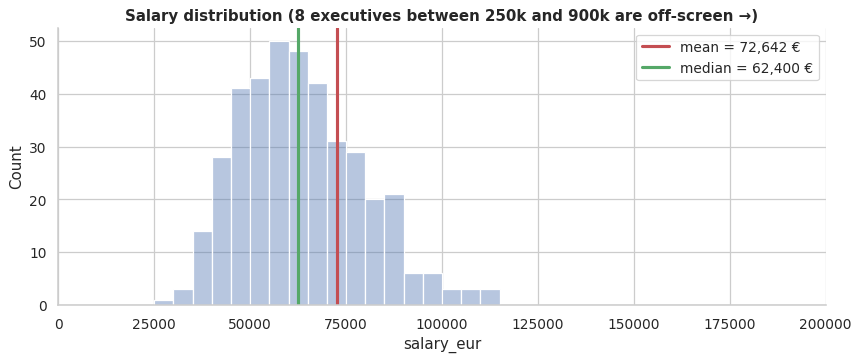

Without executives: mean 63,228 € (Δ -9,414),  median 62,150 € (Δ -250)


In [3]:
mean, median, tmean = salaries.mean(), salaries.median(), stats.trim_mean(salaries, 0.10)
mode_bin = (salaries // 5000 * 5000).mode()[0]
print(f"mean          : {mean:>10,.0f} €\nmedian        : {median:>10,.0f} €\n10%-trimmed   : {tmean:>10,.0f} €"
      f"\nmodal 5k-bin  : {mode_bin:>10,.0f} – {mode_bin + 5000:,.0f} €")
print(f"\nShare of employees earning less than the mean: {(salaries < mean).mean():.1%}")

fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(salaries, bins=np.arange(0, 200_001, 5000), color=C[0], alpha=.4, ax=ax)
ax.axvline(mean, color=C[3], lw=2.5, label=f"mean = {mean:,.0f} €"); ax.axvline(median, color=C[2], lw=2.5, label=f"median = {median:,.0f} €")
ax.set(xlim=(0, 200_000), title="Salary distribution (8 executives between 250k and 900k are off-screen →)"); ax.legend(); plt.show()

no_exec = salaries[salaries < 250_000]
print(f"Without executives: mean {no_exec.mean():,.0f} € (Δ {no_exec.mean() - mean:+,.0f}),  median {no_exec.median():,.0f} € (Δ {no_exec.median() - median:+,.0f})")

**Interpretation.** Eight people (2 % of staff) lift the mean by more than €9k, so that about 71 % of all employees earn less than "the average". The median and the trimmed mean are almost unaffected by the executives — that is robustness in action.

**Recommendation:** quote the **median** and say so: *"The typical (median) salary is about €62k; half of our employees earn between €51k and €75k."* Giving the quartiles along with the median is more informative than any single number and sets expectations honestly.

### ✍️ Exercise 1.2 — *Spread*: Which courier can promise "delivered within 48 h"? (Logistics)

An online shop compares two couriers. Both advertise "average delivery time: 36 hours". The shop wants to promise customers **delivery within 48 h** and accepts that at most 5 % of parcels break the promise.

**Tasks**
1. Compare mean, std, IQR, CV and the 95th percentile of both couriers.
2. Visualise both distributions in one figure (boxplot *and* ECDF).
3. What fraction of parcels arrives later than 48 h for each courier? Which courier do you choose?
4. What delivery promise (in hours) could each courier keep for 95 % of parcels?

In [4]:
g = np.random.default_rng(102)
deliveries = pd.DataFrame({"courier": ["SwiftShip"] * 800 + ["ParcelPal"] * 800,
                           "hours": np.concatenate([g.normal(36, 4, 800), 18 + g.gamma(2.0, 9.0, 800)])})
deliveries.groupby("courier").hours.mean().round(1)

courier
ParcelPal    36.5
SwiftShip    35.7
Name: hours, dtype: float64

,mean,std,IQR,CV,P95,late
courier,,,,,,
ParcelPal,36.480,13.189,17.274,0.362,60.288,0.166
SwiftShip,35.687,3.991,5.387,0.112,42.400,0.002


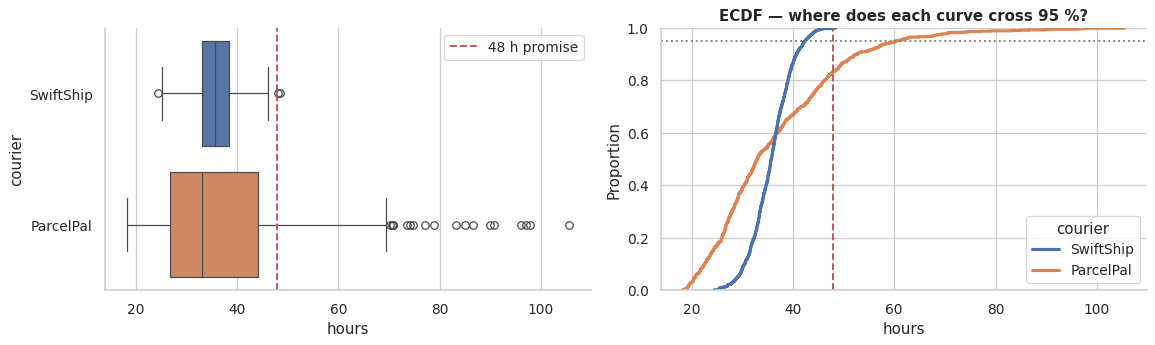

In [5]:
tab = deliveries.groupby("courier").hours.agg(mean="mean", std="std", IQR=stats.iqr, CV=lambda s: s.std() / s.mean(),
                                               P95=lambda s: s.quantile(.95), late=lambda s: (s > 48).mean())
display(tab.round(3))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(deliveries, x="hours", y="courier", ax=a1, palette=[C[0], C[1]]); a1.axvline(48, color=C[3], ls="--", label="48 h promise"); a1.legend()
sns.ecdfplot(deliveries, x="hours", hue="courier", ax=a2, lw=2.5, palette=[C[0], C[1]])
a2.axvline(48, color=C[3], ls="--"); a2.axhline(.95, color="grey", ls=":"); a2.set_title("ECDF — where does each curve cross 95 %?")
plt.tight_layout(); plt.show()

**Interpretation.** The means are identical, yet the couriers are completely different. *SwiftShip* is consistent (std ≈ 4 h); fewer than 1 % of parcels take longer than 48 h, and it could even promise ≈ 42 h. *ParcelPal* is often faster (its median is *below* SwiftShip's!) but has a long right tail: about 17 % of parcels are late, and an honest 95 % promise would be ≈ 60 h.

**Lesson:** service levels live in the **tails**, not in the mean. For any "guaranteed within …" question, look at upper percentiles and the ECDF.

### ✍️ Exercise 1.3 — *Outliers*: Cleaning a cold-chain temperature log (IoT / quality assurance)

A pharma warehouse logs the temperature of a vaccine fridge every 5 minutes (target 2–8 °C). The sensor occasionally produces glitches (readings like 85 °C or −40 °C). QA must report mean temperature and variability — a single accepted glitch would ruin the report, a wrongly deleted *real* excursion could hide a safety problem.

**Tasks**
1. Plot the time series. What do you see?
2. Flag outliers with (a) the classic z-score rule (|z| > 3) and (b) the robust MAD rule (> 3.5). How many points does each rule flag, and *which kind* of anomaly does each find?
3. The log also contains a *real* event (a door left open around reading 1200–1230). Which rule sees it? Why does the other one miss it?
4. Report mean ± std for (i) the raw log, (ii) after deleting everything the robust rule flags, (iii) after deleting only physically impossible values (outside −10 … 50 °C). Which version belongs in the QA report?

In [6]:
g = np.random.default_rng(103)
n = 2016                                                       # one week of 5-minute readings
temp = 5 + 0.6 * np.sin(np.arange(n) * 2 * np.pi / 288) + g.normal(0, 0.35, n)
temp[1200:1230] += np.linspace(0, 4.5, 30)                     # real event: door left open, temperature climbs
glitch_idx = g.choice(n, 25, replace=False)
temp[glitch_idx] = g.choice([85.0, -40.0, 127.0], 25)          # sensor glitches
log = pd.Series(temp, index=pd.date_range("2026-03-02", periods=n, freq="5min"), name="temp_C")
log.describe().round(2)

count    2016.00
mean        5.33
std         7.88
min       -40.00
25%         4.60
50%         5.00
75%         5.44
max       127.00
Name: temp_C, dtype: float64

classic z-score :  25 flagged  (25 glitches, 0 door-event readings)
robust MAD rule :  43 flagged  (25 glitches, 18 door-event readings)
z-score of the hottest door-event reading: 0.65  -> invisible for the classic rule

raw log                 : mean = 5.33 °C, std = 7.88 °C, max = 127.0 °C
robust-flagged removed  : mean = 5.01 °C, std = 0.55 °C, max = 7.1 °C
only impossible removed : mean = 5.04 °C, std = 0.66 °C, max = 10.4 °C


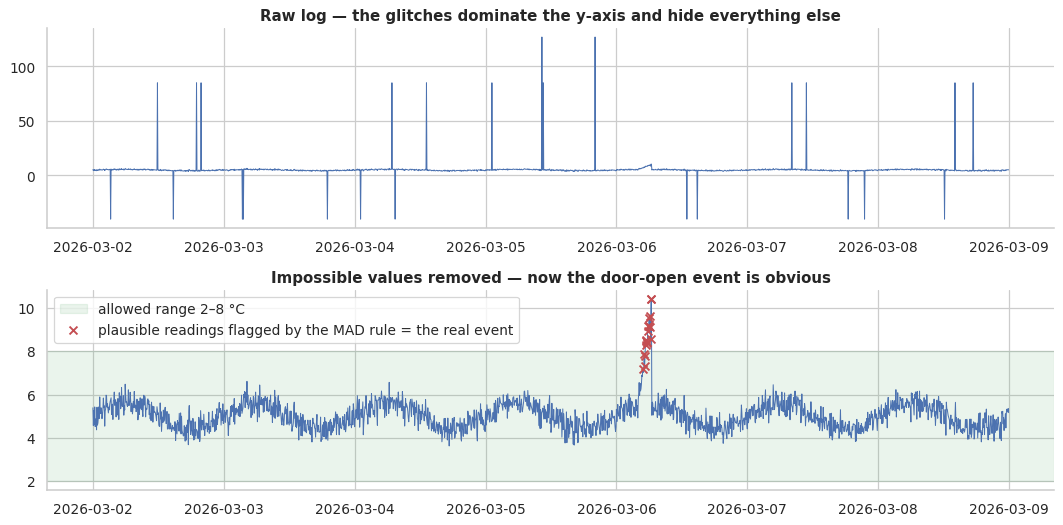

In [7]:
z  = (log - log.mean()).abs() / log.std()
rz = (log - log.median()).abs() / stats.median_abs_deviation(log, scale="normal")
flag_z, flag_r = z > 3, rz > 3.5
impossible = (log < -10) | (log > 50)                       # domain knowledge: the sensor cannot physically read this
door = pd.Series(False, index=log.index); door.iloc[1200:1230] = True

print(f"classic z-score : {flag_z.sum():>3} flagged  ({(flag_z & impossible).sum()} glitches, {(flag_z & door & ~impossible).sum()} door-event readings)")
print(f"robust MAD rule : {flag_r.sum():>3} flagged  ({(flag_r & impossible).sum()} glitches, {(flag_r & door & ~impossible).sum()} door-event readings)")
print(f"z-score of the hottest door-event reading: {z[door & ~impossible].max():.2f}  -> invisible for the classic rule\n")
for name, keep in [("raw log", slice(None)), ("robust-flagged removed", ~flag_r), ("only impossible removed", ~impossible)]:
    print(f"{name:<24}: mean = {log[keep].mean():.2f} °C, std = {log[keep].std():.2f} °C, max = {log[keep].max():.1f} °C")

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 6))
a1.plot(log, lw=.8, color=C[0]); a1.set_title("Raw log — the glitches dominate the y-axis and hide everything else")
ok = log[~impossible]
a2.plot(ok, lw=.8, color=C[0]); a2.axhspan(2, 8, color=C[2], alpha=.12, label="allowed range 2–8 °C")
hit = flag_r & ~impossible
a2.scatter(log[hit].index, log[hit], color=C[3], marker="x", s=40, zorder=3, label="plausible readings flagged by the MAD rule = the real event")
a2.set_title("Impossible values removed — now the door-open event is obvious"); a2.legend(loc="upper left")
plt.tight_layout(); plt.show()

**Interpretation.**
* The glitches (85, 127, −40 °C) are so extreme that *both* rules catch all 25 of them.
* But they inflate the standard deviation from ≈ 0.6 °C to ≈ 7.9 °C. Measured with this corrupted yardstick the door-open excursion (up to ≈ 10 °C) has a z-score below 1 — the classic rule is blind to it (**masking**). The robust rule flags the hottest readings of the event as well.
* Deleting *everything* the robust rule flags gives the prettiest numbers — and **hides a genuine cold-chain violation**. The correct QA report uses version (iii): remove only physically impossible values, keep the real excursion, and report it separately (max ≈ 10 °C, above the 8 °C limit for roughly an hour).

**A detection rule flags candidates; domain knowledge decides what happens to them.**

### ✍️ Exercise 1.4 — *Full EDA*: Profiling wines from three growers (real data)

A wine cooperative buys grapes from three cultivars. The lab has chemical analyses of 178 wines (`sklearn.datasets.load_wine`). Management asks for a one-page descriptive profile.

**Tasks**
1. For `alcohol`, `color_intensity` and `proline`, compute per cultivar: n, mean, median, std, IQR and skewness.
2. Which variable is the most skewed? Which has the highest *relative* variability (CV)?
3. Create a figure that compares the three cultivars for all three variables (your choice of plot — justify it).
4. Write three sentences for management: what distinguishes the cultivars?

In [8]:
from sklearn.datasets import load_wine
w = load_wine(as_frame=True)
wine = w.frame[["alcohol", "color_intensity", "proline"]].copy()
wine["cultivar"] = w.target.map({0: "A", 1: "B", 2: "C"})
wine.head()

,alcohol,color_intensity,proline,cultivar
0,14.23,5.64,1065.0,A
1,13.20,4.38,1050.0,A
2,13.16,5.68,1185.0,A
3,14.37,7.80,1480.0,A
4,13.24,4.32,735.0,A


cultivar                      A       B       C
alcohol         count     59.00   71.00   48.00
                mean      13.74   12.28   13.15
                median    13.75   12.29   13.16
                std        0.46    0.54    0.53
                iqr        0.70    0.60    0.70
                skew       0.07    0.57    0.15
color_intensity count     59.00   71.00   48.00
                mean       5.53    3.09    7.40
                median     5.40    2.90    7.55
                std        1.24    0.92    2.31
                iqr        1.67    0.86    3.79
                skew       0.57    1.02    0.29
proline         count     59.00   71.00   48.00
                mean    1115.71  519.51  629.90
                median  1095.00  495.00  627.50
                std      221.52  157.21  115.10
                iqr      292.50  218.50  150.00
                skew       0.22    0.87    0.31

Overall skewness:
 alcohol           -0.05
color_intensity    0.87
proline            0.77

Overall CV (std/mean):
 alcohol            0.06
color_intensity    0.46
proline            0.42


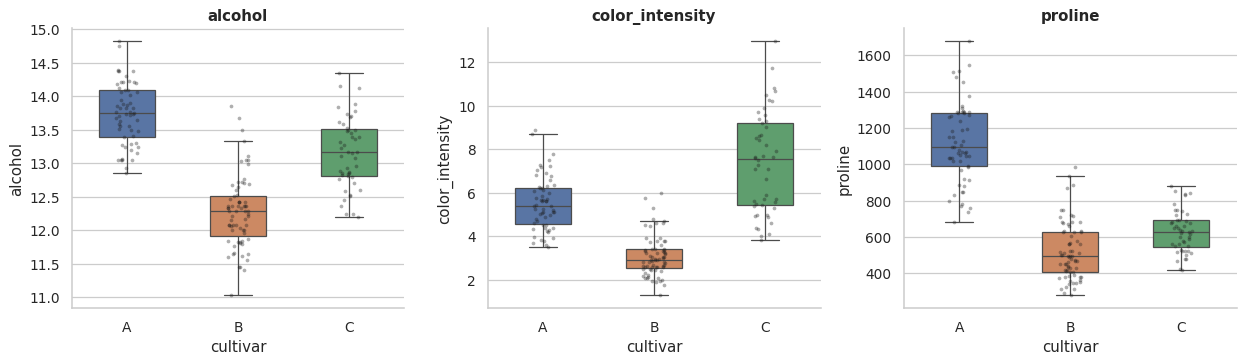

In [9]:
cols = ["alcohol", "color_intensity", "proline"]
prof = wine.groupby("cultivar")[cols].agg(["count", "mean", "median", "std", stats.iqr, stats.skew]).round(2)
display(prof.T)
print("Overall skewness:\n", wine[cols].skew().round(2).to_string())
print("\nOverall CV (std/mean):\n", (wine[cols].std() / wine[cols].mean()).round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, c in zip(axes, cols):
    sns.boxplot(wine, x="cultivar", y=c, ax=ax, palette="deep", width=.5, showfliers=False)
    sns.stripplot(wine, x="cultivar", y=c, ax=ax, color="k", alpha=.35, size=3)
    ax.set_title(c)
plt.tight_layout(); plt.show()

**Interpretation.** With only ~50–70 wines per group, *box + strip plots* are a good choice: they show the robust summary and every single observation (a violin/KDE would over-smooth such small groups).

* **Alcohol:** A (≈ 13.7 %) > C (≈ 13.2 %) > B (≈ 12.3 %); low relative variability (CV ≈ 6 %).
* **Colour intensity:** C is darkest and by far the most variable (IQR 3.8 vs 0.9 for B); B is pale.
* **Proline:** A has about twice the proline of B and C — the single best discriminator. Proline (CV ≈ 42 %, skew ≈ 0.8) and colour intensity (CV ≈ 46 %, skew ≈ 0.9) are both right-skewed with high relative variability, so medians/IQRs are the safer summaries for them.

*Message for management:* cultivar A produces strong, proline-rich wines; B light and pale wines; C dark wines with moderate alcohol but very inconsistent colour — a candidate for process improvement.